For a discussion of the data, look [here.](https://archive.ics.uci.edu/dataset/186/wine+quality)

```
fixed acidity
   2 - volatile acidity
   3 - citric acid
   4 - residual sugar
   5 - chlorides
   6 - free sulfur dioxide
   7 - total sulfur dioxide
   8 - density
   9 - pH
   10 - sulphates
   11 - alcohol
Output variable (based on sensory data): 
   12 - quality (score between 0 and 10)
``


In [1]:
## Your code goes here.  You will need to add more imports to those given
import numpy as np
from sklearn.datasets import load_wine
data = load_wine(as_frame=True)
df = data.data
target= data.target
target_names= data.target_names

In [7]:
len(set(target))

3

In [2]:
target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [18]:
df.columns

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='object')

In [5]:
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


print(f"0: {(target == 0).sum()}    1: {(target == 1).sum()}    2: {(target == 2).sum()}")

##  Exercise one

Plot magnesium versus color_intensity using a scatterplot.  Color the scatter points by class

In [24]:
print(df.plot.__doc__)


    Make plots of Series or DataFrame.

    Uses the backend specified by the
    option ``plotting.backend``. By default, matplotlib is used.

    Parameters
    ----------
    data : Series or DataFrame
        The object for which the method is called.
    x : label or position, default None
        Only used if data is a DataFrame.
    y : label, position or list of label, positions, default None
        Allows plotting of one column versus another. Only used if data is a
        DataFrame.
    kind : str
        The kind of plot to produce:

        - 'line' : line plot (default)
        - 'bar' : vertical bar plot
        - 'barh' : horizontal bar plot
        - 'hist' : histogram
        - 'box' : boxplot
        - 'kde' : Kernel Density Estimation plot
        - 'density' : same as 'kde'
        - 'area' : area plot
        - 'pie' : pie plot
        - 'scatter' : scatter plot (DataFrame only)
        - 'hexbin' : hexbin plot (DataFrame only)
    ax : matplotlib axes object, d

<Axes: xlabel='magnesium', ylabel='color_intensity'>

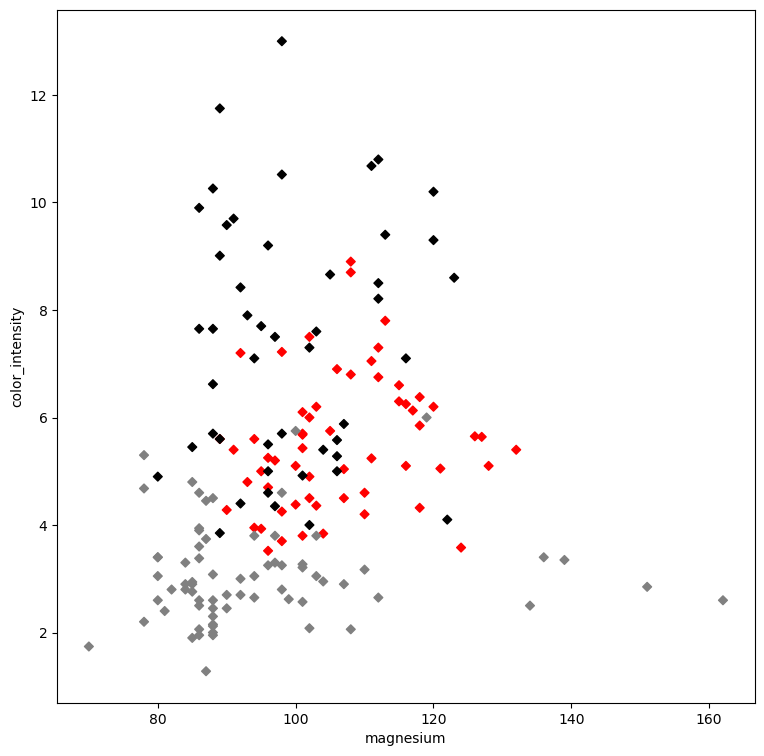

In [34]:


df.plot(x="magnesium",y="color_intensity",kind="scatter",color=colors[target],marker="D",figsize=(9,9))

##  Exercise Two
Do a hexbin plot ofthe same variables.  Look at an example of a hexbin plot [here.](https://matplotlib.org/stable/gallery/statistics/hexbin_demo.html)

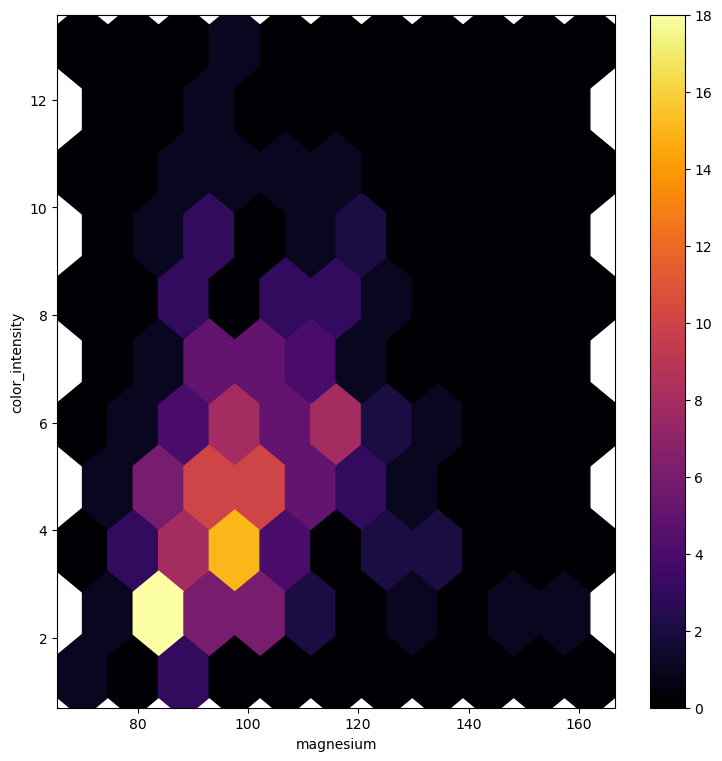

In [39]:
_ = df.plot(x="magnesium",y="color_intensity",kind="hexbin",gridsize=10, cmap='inferno', figsize=(9,9))

##  Exercise Three

Do a plot with 4 subplots

```python
from matplotlib import pyplot as plt
(fg, ax_grid) = plt.subplots(2,2,figsize=(9,9))
axes = (ax_grid[0,0],ax_grid[0,1],ax_grid[1,0],ax_grid[1,1])
```

Each subplot should do a scatterplot of one pair of variables 
from `df`

```python
df.plot(.... ax=axes[i])
```

Here are the four variable pairs your figure should scatterplot:

```python
(("magnesium","color_intensity"),("magnesium","alcalinity_of_ash"),
 ("magnesium","malic_acid"),("magnesium", "hue"))
```


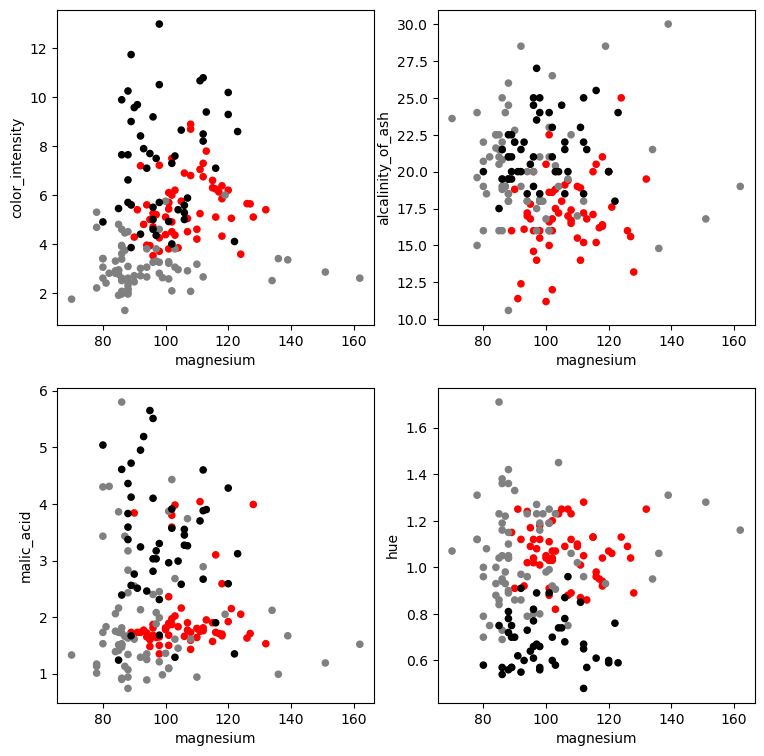

In [48]:
from matplotlib import pyplot as plt

(fg, ax_grid) = plt.subplots(2,2,figsize=(9,9))
axes = (ax_grid[0,0],ax_grid[0,1],ax_grid[1,0],ax_grid[1,1])

for (i,(x,y)) in  enumerate((("magnesium","color_intensity"),("magnesium","alcalinity_of_ash"),
                                 ("magnesium","malic_acid"),("magnesium", "hue"))):
        df.plot(x=x,y=y, kind="scatter", color=colors[target],ax=axes[i])

##  Exercise Four

Is it true that no member of class 2 has magnesium levels greater than 120?

Write one expression that verifies or disconfirms this claim.

In [52]:
(~(target[df["magnesium"] > 120] == 2)).all()

np.False_



What percentage of class 1 has alcalinity of ash greater than or eaul to 18?

In [54]:
print ((target[df['alcalinity_of_ash'] >= 17] == 1).sum())
(target == 1).sum()

61


np.int64(71)